# 1qb-DB V3 — vz-free X/Y $\pi$ delivery waveforms

This compact notebook compares the delivered Novera A–F $X(\pi)$ and $Y(\pi)$ waveforms, then defines three deterministic-benchmarking (DB) unit cells for every arm. It intentionally contains only coherent three-level propagation and one deliberate amplitude-error setting; it does **not** add calibration, detuning, dissipation, scans, optimisation, or checks beyond the requested experiment.

The DB preparation and readout are both $|+\rangle=(|0\rangle+|1\rangle)/\sqrt{2}$. This notebook plays the delivered `_vzfree.csv` pulse for every gate. These files already include the drive-phase pre-rotation $\psi=-\phi_{\rm vz}/2$, so each played $\pi$ pulse lands on its target gate and needs no virtual-Z frame update afterward. The loader still checks that both the canonical and vz-free delivery paths exist, but only the vz-free waveform is propagated.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy.linalg import expm


def find_repo_root(start=None):
    """Find the repository from any usual notebook working directory."""
    start = Path.cwd() if start is None else Path(start)
    marker = Path("proposals/Novera_work/delivery_1GSa/delivery_metadata.json")
    for candidate in (start, *start.parents):
        if (candidate / marker).is_file():
            return candidate
    raise FileNotFoundError(
        f"Could not find {marker} above current working directory {start}. "
        "Open this notebook from inside the curve_optimize_tool repository."
    )


REPO_ROOT = find_repo_root()
DELIVERY_DIR = REPO_ROOT / "proposals" / "Novera_work" / "delivery_1GSa"
METADATA_PATH = DELIVERY_DIR / "delivery_metadata.json"
assert METADATA_PATH.is_file(), f"Missing delivery metadata: {METADATA_PATH}"
with METADATA_PATH.open() as stream:
    DELIVERY = json.load(stream)

DEVICE = DELIVERY["device"]
ARMS = tuple(DELIVERY["gates"]["Xpi"]["arms"])
assert ARMS == tuple("ABCDEF"), f"Expected A–F delivery arms, found {ARMS}"
print(
    f"Loaded {DELIVERY['package']}: arms {', '.join(ARMS)}, "
    f"T = {DEVICE['gate_time_ns']:g} ns at {DEVICE['sample_rate_GSa']:g} GSa/s"
)


Matplotlib is building the font cache; this may take a moment.


Loaded Novera single-qubit pi-gate waveform delivery: arms A, B, C, D, E, F, T = 50 ns at 1 GSa/s


## Load the vz-free X$\pi$ and Y$\pi$ waveforms

Each metadata entry supplies a canonical CSV and a `_vzfree.csv` companion. The loader asserts that both delivery paths exist, then reads the `csv_vzfree` file used by the figures and DB experiment. Its drive phase is already pre-rotated, so no virtual-Z update is applied after playback. All 12 played files must have the same midpoint time grid.

In [2]:
def read_waveform_csv(path, entry):
    """Read a delivery CSV with its long '#' header explicitly skipped."""
    columns, rows = None, []
    with Path(path).open() as stream:
        for raw_line in stream:
            line = raw_line.strip()
            if not line or line.startswith("#"):
                continue
            if columns is None:
                columns = [column.strip() for column in line.split(",")]
                assert columns and all(columns), f"Invalid CSV header in {path}"
                assert len(columns) == len(set(columns)), f"Duplicate CSV columns in {path}"
                continue
            values = [value.strip() for value in line.split(",")]
            assert len(values) == len(columns), (
                f"Column count mismatch in {path}: expected {len(columns)}, "
                f"got {len(values)} for row {line!r}"
            )
            try:
                rows.append([float(value) for value in values])
            except ValueError as exc:
                raise AssertionError(f"Non-numeric data row in {path}: {line!r}") from exc

    assert columns is not None, f"No non-comment CSV header found in {path}"
    assert rows, f"No numeric data rows found in {path}"
    array = np.asarray(rows, dtype=float)
    assert array.ndim == 2 and array.shape[1] == len(columns), (path, array.shape, columns)
    data = dict(zip(columns, array.T))
    needed = {"t_ns", "Omega_x_rad_per_ns", "Omega_y_rad_per_ns"}
    assert needed <= set(data), f"Missing {needed - set(data)} in {path}"

    time = np.asarray(data["t_ns"], dtype=float)
    assert len(time) == entry["n_samples"], (path, len(time), entry["n_samples"])
    assert np.allclose(np.diff(time), entry["dt_ns"]), (path, "time grid does not match metadata")
    return {
        "t_ns": time,
        "omega_x": np.asarray(data["Omega_x_rad_per_ns"], dtype=float),
        "omega_y": np.asarray(data["Omega_y_rad_per_ns"], dtype=float),
        "dt_ns": float(entry["dt_ns"]),
        "path": Path(path),
    }


def load_vzfree_waveforms(delivery, delivery_dir):
    waveforms, files = {}, {}
    reference_time = None
    for gate_name in ("Xpi", "Ypi"):
        waveforms[gate_name], files[gate_name] = {}, {}
        gate_arms = delivery["gates"][gate_name]["arms"]
        assert tuple(gate_arms) == ARMS, f"{gate_name} arm keys disagree with Xpi"
        for arm in ARMS:
            entry = gate_arms[arm]
            canonical_path = delivery_dir / gate_name / entry["csv"]
            vzfree_path = delivery_dir / gate_name / entry["csv_vzfree"]
            assert canonical_path.is_file(), f"Missing canonical CSV: {canonical_path}"
            assert vzfree_path.is_file(), f"Missing paired vz-free CSV: {vzfree_path}"
            vzfree = read_waveform_csv(vzfree_path, entry)
            time = vzfree["t_ns"]
            if reference_time is None:
                reference_time = time
            else:
                assert np.allclose(time, reference_time), (arm, gate_name, "time grid mismatch")
            waveforms[gate_name][arm] = vzfree
            files[gate_name][arm] = {"canonical": canonical_path, "vzfree": vzfree_path}
    return waveforms, files


WAVEFORMS, WAVEFORM_FILES = load_vzfree_waveforms(DELIVERY, DELIVERY_DIR)
for arm in ARMS:
    print(
        f"{arm}: Xπ {len(WAVEFORMS['Xpi'][arm]['t_ns'])} samples — "
        f"{WAVEFORM_FILES['Xpi'][arm]['vzfree'].name}; "
        f"Yπ {WAVEFORM_FILES['Ypi'][arm]['vzfree'].name}"
    )


A: Xπ 50 samples — Xpi_novera_A_gaussian_vzfree.csv; Yπ Ypi_novera_A_gaussian_vzfree.csv
B: Xπ 50 samples — Xpi_novera_B_gaussian_drag_vzfree.csv; Yπ Ypi_novera_B_gaussian_drag_vzfree.csv
C: Xπ 50 samples — Xpi_novera_C_optimized_vzfree.csv; Yπ Ypi_novera_C_optimized_vzfree.csv
D: Xπ 50 samples — Xpi_novera_D_optimized_fluence_cap_vzfree.csv; Yπ Ypi_novera_D_optimized_fluence_cap_vzfree.csv
E: Xπ 50 samples — Xpi_novera_E_optimized_ad_exact_vzfree.csv; Yπ Ypi_novera_E_optimized_ad_exact_vzfree.csv
F: Xπ 50 samples — Xpi_novera_F_optimized_ad_robust_vzfree.csv; Yπ Ypi_novera_F_optimized_ad_robust_vzfree.csv


## Played vz-free waveforms used by DB

These are the vz-free $X(\pi)$ and $Y(\pi)$ files used by the DB calculation. Their drive phase already includes the delivery pre-rotation, so playback implements the target gate without a subsequent virtual-Z update. The vertical scale is $\Omega/(2\pi)$ in MHz; each panel shows the two physical control quadratures.

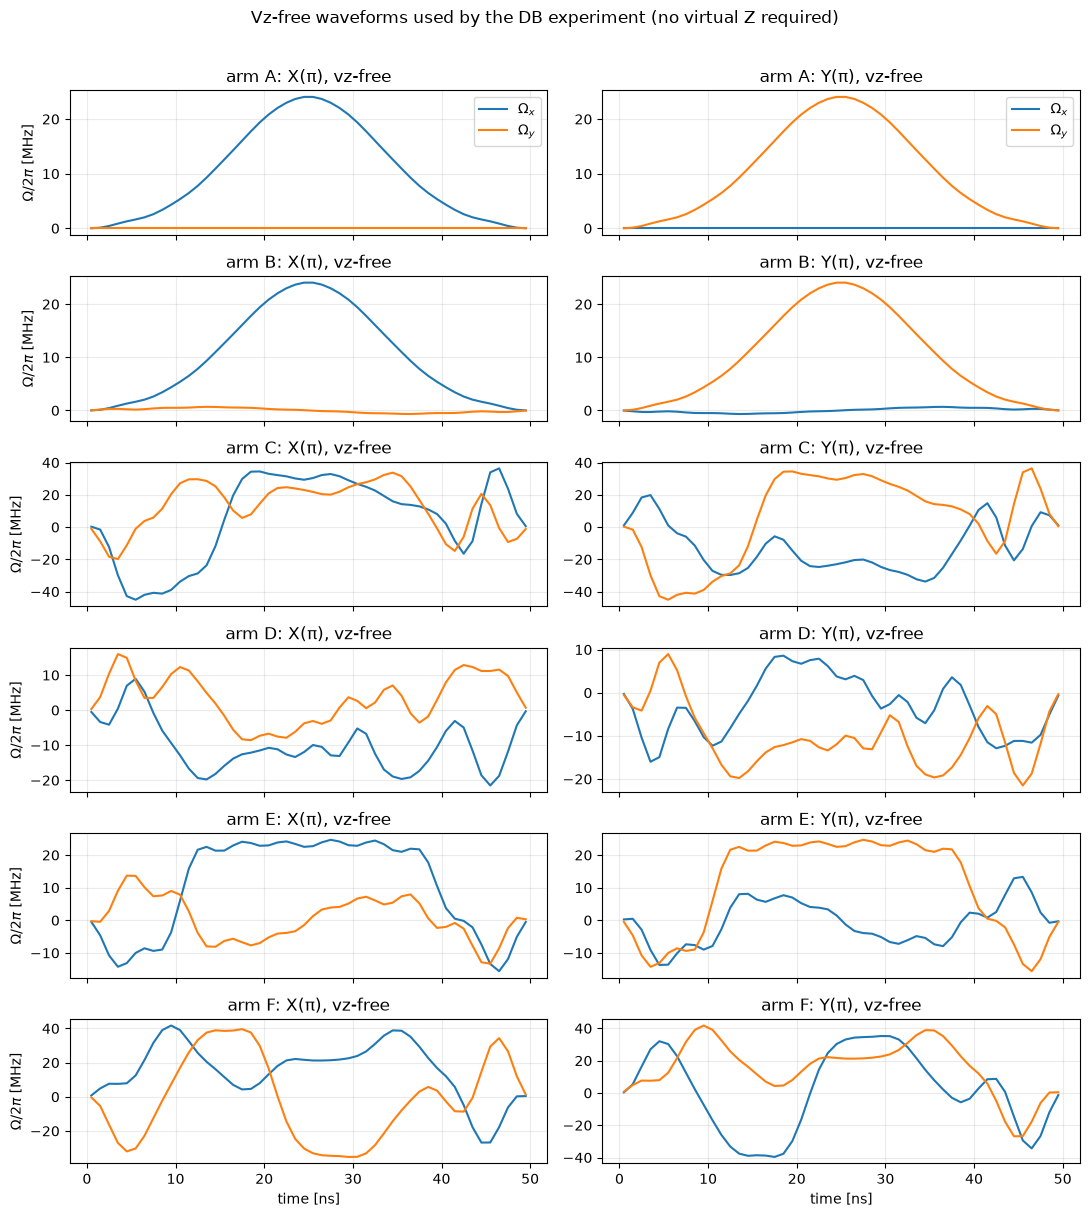

In [3]:
fig, axes = plt.subplots(len(ARMS), 2, figsize=(11, 2.0 * len(ARMS)), sharex=True)
for row, arm in enumerate(ARMS):
    for col, gate_name in enumerate(("Xpi", "Ypi")):
        waveform = WAVEFORMS[gate_name][arm]
        axis = axes[row, col]
        axis.plot(waveform["t_ns"], waveform["omega_x"] / (2 * np.pi) * 1e3, label=r"$\Omega_x$")
        axis.plot(waveform["t_ns"], waveform["omega_y"] / (2 * np.pi) * 1e3, label=r"$\Omega_y$")
        axis.set_title(f"arm {arm}: {gate_name[:-2]}(π), vz-free")
        axis.grid(alpha=0.25)
        if row == 0:
            axis.legend(loc="upper right")
        if col == 0:
            axis.set_ylabel(r"$\Omega/2\pi$ [MHz]")
        if row == len(ARMS) - 1:
            axis.set_xlabel("time [ns]")
fig.suptitle("Vz-free waveforms used by the DB experiment (no virtual Z required)", y=1.01)
fig.tight_layout()
plt.show()


## DB experiment definition

For every arm, prepare $|+\rangle$ and repeat one of the following unit cells $n=0,\ldots,N$ times:

1. `XX`: $U_{\rm cell}=U_X U_X$.
2. `YY`: $U_{\rm cell}=U_Y U_Y$.
3. `XXb`: first $X$, then $X_b$, so $U_{\rm cell}=U_{X_b}U_X$.

Here $X_b$ reverses the **entire control Hamiltonian** while retaining multiplicative amplitude error: $H_c(t)\mapsto-(1+\epsilon)H_c(t)$. Thus both $\Omega_x$ and $\Omega_y$ are negated, while the bare three-level anharmonicity term is unchanged. This `XXb` construction is kept unchanged from V2 solely to isolate the vz-free waveform selection; it is not claimed here as an independent validation of the paper's inverse-gate protocol. The sole plotted readout is $P_+=|\langle+|\psi\rangle|^2$, comparing no deliberate error to one injected value.

In [4]:
# Deliberate control-error setting and sequence length; edit these two experiment knobs only.
INJECTED_ERROR = 0.02
N_REPEATS = 100
ERROR_LEVELS = (0.0, INJECTED_ERROR)

# Device quantities are read from delivery_metadata.json, never duplicated as notebook constants.
DELTA = 2 * np.pi * float(DEVICE["anharmonicity_GHz"])
a = np.array([[0, 1, 0], [0, 0, np.sqrt(2)], [0, 0, 0]], dtype=complex)
DX = 0.5 * (a + a.conj().T)
DY = 0.5j * (a.conj().T - a)
H_BARE = np.diag([0.0, 0.0, DELTA]).astype(complex)
PLUS = np.array([1.0, 1.0, 0.0], dtype=complex) / np.sqrt(2)


def gate_propagator(waveform, epsilon, control_sign=1.0):
    """Three-level midpoint/sample-and-hold propagator for one delivered gate."""
    unitary = np.eye(3, dtype=complex)
    for omega_x, omega_y in zip(waveform["omega_x"], waveform["omega_y"]):
        h_control = control_sign * (1.0 + epsilon) * (omega_x * DX + omega_y * DY)
        step = expm(-1j * (H_BARE + h_control) * waveform["dt_ns"])
        unitary = step @ unitary  # newest midpoint step is on the left
    return unitary


def db_trace(unit_cell, repeats=N_REPEATS):
    """Pure-state DB trace: repeat one unit cell and read only P_plus."""
    psi = PLUS.copy()
    p_plus = np.empty(repeats + 1)
    p_plus[0] = abs(np.vdot(PLUS, psi)) ** 2
    for repeat in range(repeats):
        psi = unit_cell @ psi
        p_plus[repeat + 1] = abs(np.vdot(PLUS, psi)) ** 2
    return p_plus


## Compute the requested DB traces

The calculation below has exactly $6\times3\times2$ traces: arms A–F, the three unit cells, and $\epsilon=0$ versus $\epsilon=2\%$. `XXb` is explicitly ordered `Uxb @ Ux`, corresponding to first applying $X$ and then $X_b$.

In [5]:
UNIT_ORDER = ("XX", "YY", "XXb")
TRACES = {arm: {unit: {} for unit in UNIT_ORDER} for arm in ARMS}

for arm in ARMS:
    for epsilon in ERROR_LEVELS:
        ux = gate_propagator(WAVEFORMS["Xpi"][arm], epsilon, control_sign=+1.0)
        uy = gate_propagator(WAVEFORMS["Ypi"][arm], epsilon, control_sign=+1.0)
        uxb = gate_propagator(WAVEFORMS["Xpi"][arm], epsilon, control_sign=-1.0)
        unit_cells = {
            "XX": ux @ ux,
            "YY": uy @ uy,
            "XXb": uxb @ ux,  # first X, then Xb
        }
        for unit_name, unit_cell in unit_cells.items():
            TRACES[arm][unit_name][epsilon] = db_trace(unit_cell)

assert sum(len(TRACES[arm][unit]) for arm in ARMS for unit in UNIT_ORDER) == 6 * 3 * 2
print(f"Prepared {6 * 3 * 2} P_plus traces: 6 arms × 3 unit cells × 2 error settings.")


Prepared 36 P_plus traces: 6 arms × 3 unit cells × 2 error settings.


## DB traces: $P_+$ versus repeated unit cells

One subplot is shown per arm. Within each subplot, colour identifies the unit cell (`XX`, `YY`, or `XXb`) and line style identifies the deliberate amplitude-error setting: dashed for the no-injection reference and solid for the injected error. The two figure-level legends state these encodings separately.

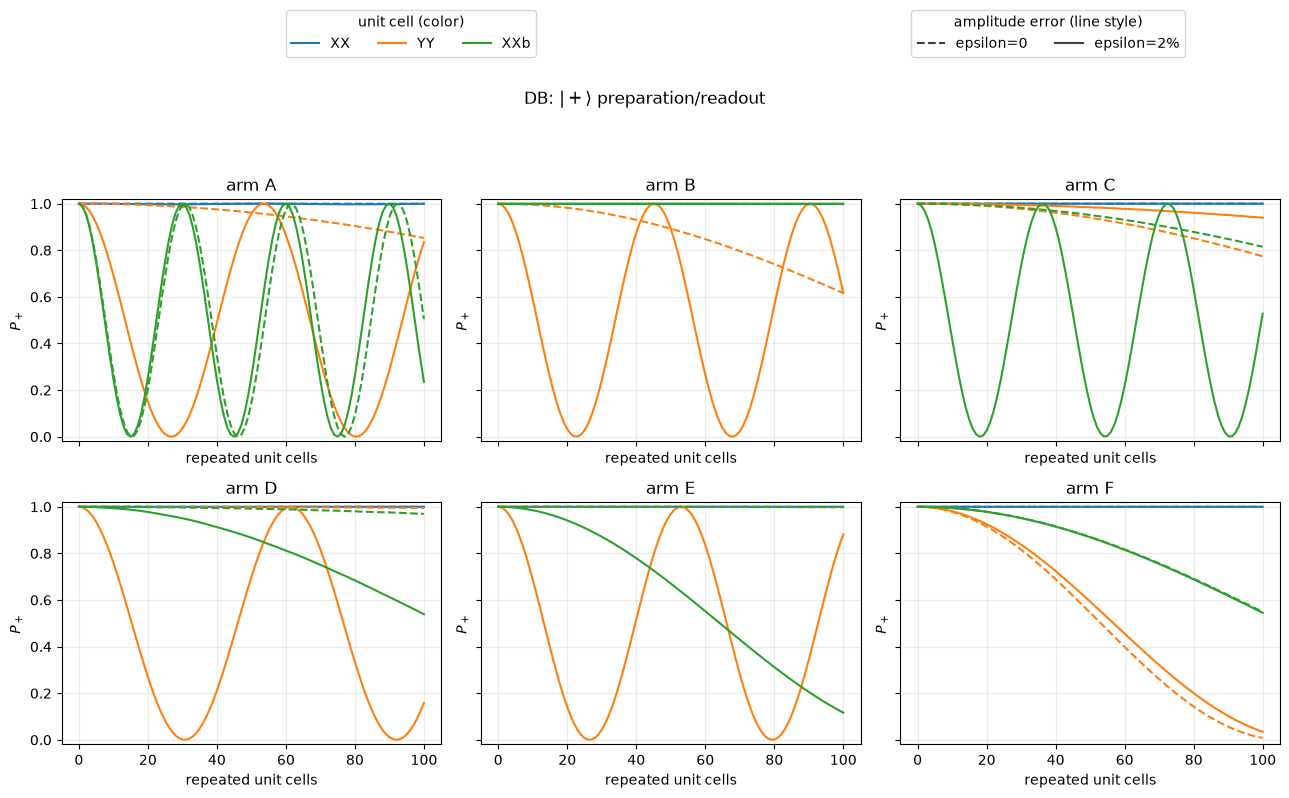

In [6]:
from matplotlib.lines import Line2D

repeats = np.arange(N_REPEATS + 1)
UNIT_COLORS = {"XX": "tab:blue", "YY": "tab:orange", "XXb": "tab:green"}
fig, axes = plt.subplots(2, 3, figsize=(13, 8), sharex=True, sharey=True)
for axis, arm in zip(axes.flat, ARMS):
    for unit_name in UNIT_ORDER:
        color = UNIT_COLORS[unit_name]
        axis.plot(repeats, TRACES[arm][unit_name][0.0], "--", color=color)
        axis.plot(repeats, TRACES[arm][unit_name][INJECTED_ERROR], "-", color=color)
    axis.set_title(f"arm {arm}")
    axis.set_xlabel("repeated unit cells")
    axis.set_ylabel(r"$P_+$")
    axis.set_ylim(-0.02, 1.02)
    axis.grid(alpha=0.25)

unit_handles = [Line2D([], [], color=UNIT_COLORS[name], label=name) for name in UNIT_ORDER]
error_handles = [
    Line2D([], [], color="0.25", linestyle="--", label="epsilon=0"),
    Line2D([], [], color="0.25", linestyle="-", label=f"epsilon={INJECTED_ERROR:.0%}"),
]
fig.legend(unit_handles, [handle.get_label() for handle in unit_handles], title="unit cell (color)",
           loc="upper center", bbox_to_anchor=(0.32, 1.00), ncol=3)
fig.legend(error_handles, [handle.get_label() for handle in error_handles], title="amplitude error (line style)",
           loc="upper center", bbox_to_anchor=(0.81, 1.00), ncol=2)
fig.suptitle(r"DB: $|+\rangle$ preparation/readout", y=0.89)
fig.tight_layout(rect=(0, 0, 1, 0.84))
plt.show()


## Reading the figure

Compare the solid and dashed curves within each arm/unit-cell panel. Their separation is the response to the single injected amplitude-error setting under the stated coherent three-level model. Because every propagated waveform is the vz-free delivery variant, its drive-phase pre-rotation is already included and no virtual-Z frame update is required. This notebook leaves the numerical comparison to the executed experiment; it deliberately does not pre-fill a ranking or any performance conclusion.